In [ ]:
# The Scenario: You are a climate climate_data scientist. You have been handed a 
#         massive climate_dataset from a satellite grid. To load the .npy file use 
#         np.load(“...”). The climate_data is a 3D NumPy array structured as 
#         (Latitude, Longitude, Days), and the values inside represent the 
#         daily peak temperature in Celsius. You need to clean, analyze, and 
#         transform this climate_data using only NumPy operations.
# Creating Arrays & Attributes: You load the provided climate climate_dataset. 
#         You must inspect .shape, .ndim, and .dtype to understand how the 
#         geographical coordinates and the 31 days of the month are structured. 
#         Because you will be calculating temperature anomalies later, you 
#         also need to create a blank "baseline grid" of the exact same 
#         geographical dimensions using np.zeros().
# Indexing, Slicing & Masking: 
# Slicing: The climate_dataset covers the whole globe, but you only want to analyze 
#         a specific drought-prone region. Crop the climate_data to specific 
#         latitude and longitude coordinates 
#         (e.g., climate_climate_data[20:50, 70:120, :]).
# Indexing: Isolate a "snapshot" of the entire grid for exactly Day 15 to 
#         see a cross-section of global temperatures on that specific day.
# Masking: climate_data cleaning is required. A sensor glitch caused several 
#         locations to record impossible temperatures of -99°C. Create a 
#         boolean mask to find all instances of -99 and replace them with 
#         np.nan (Not a Number) so they don't skew your later calculations.
# Vectorization, Broadcasting & Ufuncs: 
#            -   Broadcasting: Your American stakeholders need the climate_data in 
#            Fahrenheit. Convert the entire 3D array from Celsius to 
#            Fahrenheit in a single mathematical step ((climate_data * 9/5) + 32) 
#            without writing a single for loop.
#            -   Ufuncs: To model a specific heat-stress index, apply a 
#            non-linear transformation to the temperature values using 
#            np.exp() and np.log() across the entire grid simultaneously.
# Math & Stats:
#            -    Find the absolute highest and lowest valid temperatures 
#            recorded anywhere on the grid during the month 
#            (np.nanmax, np.nanmin).
#            -     Calculate the average temperature for each specific 
#            sensor location across the entire month 
#            (using np.nanmean across the "Days" axis). 
#            This will collapse your 3D array into a 2D map showing the 
#            baseline climate for each coordinate!

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Creating Arrays & Attributes
climate_data = np.load("climate_data.npy")

print(f"Climate Data Shape: {climate_data.shape}") 
print(f"Number of Dimensions: {climate_data.ndim}")
print(f"Climate Data Type: {climate_data.dtype}")
                                
baseline_grid = np.zeros(climate_data.shape[:2])

print(f"Baseline Grid Shape: {baseline_grid.shape}")

Climate Data Shape: (180, 360, 31)
Number of Dimensions: 3
Climate Data Type: float64
Baseline Grid Shape: (180, 360)


In [2]:
# SLICING
regional_data = climate_data[20:50, 70:120, :]

print(f"Regional Shape: {regional_data.shape}")

Regional Shape: (30, 50, 31)


In [3]:
# MASKING
mask = climate_data == -99
climate_data[mask] = np.nan

print(f"Number of glitches cleaned: {np.isnan(climate_data).sum()}")

Number of glitches cleaned: 4994


Shape of snapshot: (180, 360)


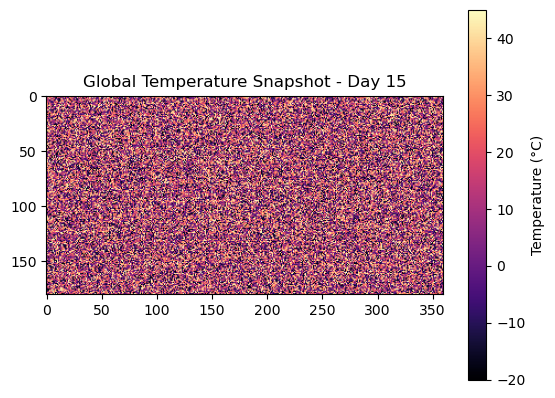

In [7]:
# INDEXING
day_15_snapshot = climate_data[:, :, 14]

print(f"Shape of snapshot: {day_15_snapshot.shape}")

plt.imshow(day_15_snapshot, cmap='magma')
plt.colorbar(label="Temperature (°C)")
plt.title("Global Temperature Snapshot - Day 15")
plt.show()

In [ ]:
# BROADCASTING
data_f = (climate_data * 9/5) + 32

print(f"Original min (C): {np.nanmin(climate_data):.2f}°C")
print(f"New min (F): {np.nanmin(data_f):.2f}°F")

day_15_f = data_f[:, :, 14]
plt.figure(figsize=(10, 5))
plt.imshow(day_15_f, cmap='inferno') 
plt.colorbar(label="Temperature (°F)")
plt.title("Global Temperature Snapshot (Day 15) - Fahrenheit")
plt.show()

Original Data Shape: (180, 360, 31)
Stress Index Shape:  (180, 360, 31)
The most dangerous heat stress occurred at:
Location Index: (Lat: 0, Lon: 17)
On Day: 5
Stress Intensity: 13.32
Which is a temp of 45.0°C


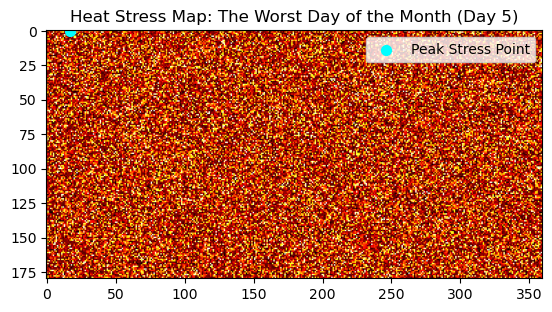

In [5]:
# UFuncs
stress_index = np.exp(climate_data / 20) + np.log(np.abs(climate_data) + 1)

print(f"Original Data Shape: {climate_data.shape}")
print(f"Stress Index Shape:  {stress_index.shape}") 

peak_index = np.nanargmax(stress_index)

lat, lon, day = np.unravel_index(peak_index, stress_index.shape)

print(f"The most dangerous heat stress occurred at:")
print(f"Location Index: (Lat: {lat}, Lon: {lon})")
print(f"On Day: {day + 1}") 
print(f"Stress Intensity: {stress_index[lat, lon, day]:.2f}")
actual_temp = climate_data[0, 17, 4] 
print(f"Which is a temp of {actual_temp}°C")

worst_day_map = stress_index[:, :, day] 

plt.imshow(worst_day_map, cmap='hot')
plt.scatter(lon, lat, color='cyan', s=50, label="Peak Stress Point") 
plt.legend()
plt.title(f"Heat Stress Map: The Worst Day of the Month (Day {day+1})")
plt.show()

Absolute Highest Temperature: 45.00°C
Absolute Lowest Temperature: -20.00°C
Baseline Map Shape: (180, 360)


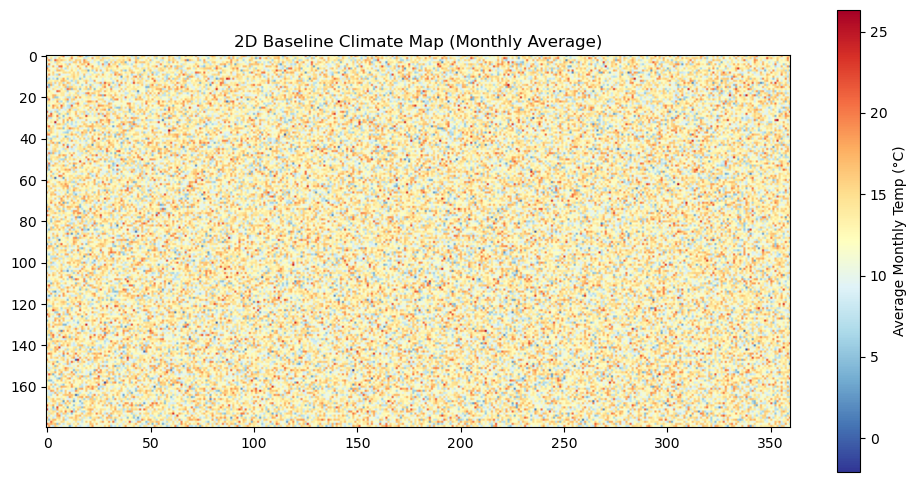

In [6]:
# MATH & STATS
highest_temp = np.nanmax(climate_data)
lowest_temp = np.nanmin(climate_data)

print(f"Absolute Highest Temperature: {highest_temp:.2f}°C")
print(f"Absolute Lowest Temperature: {lowest_temp:.2f}°C")

baseline_map = np.nanmean(climate_data, axis=2)

print(f"Baseline Map Shape: {baseline_map.shape}") 

plt.figure(figsize=(12, 6))
plt.imshow(baseline_map, cmap='RdYlBu_r') 
plt.colorbar(label="Average Monthly Temp (°C)")
plt.title("2D Baseline Climate Map (Monthly Average)")
plt.show()